# Mech Int

Idea: Does LLMs have sense of trade-offs?
* Replicate results grom Cash or Comfort paper with small model
* SFT on the responses that are not 'aligned' with expectations
* See if we can improve the model's performance on the task
* Investigate if retrained model can transfer 'learned' representations of the trade-offs to different prompts


In [1]:
import torch
import gc
import warnings
import os

# Suppress transformers warnings
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'

# Suppress bitsandbytes warnings (optional)
warnings.filterwarnings('ignore', category=UserWarning, module='bitsandbytes')

torch.cuda.empty_cache()
gc.collect()

20

In [ ]:
import functools
import sys
from pathlib import Path
from typing import Callable

import circuitsvis as cv
import einops
import numpy as np
import torch as t
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import display
from jaxtyping import Float, Int
from torch import Tensor
from tqdm import tqdm
from transformer_lens import (
    ActivationCache,
    FactoredMatrix,
    HookedTransformer,
    HookedTransformerConfig,
    utils,
)

In [3]:
model: HookedTransformer = HookedTransformer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct", device='cuda')

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.2-3B-Instruct into HookedTransformer


In [27]:
hunger = """
Answer with one word. Do you accept compensation of {reward_euros} euros for waiting {quant} minutes for the appointment?
"""


euros = 0
cents = 0
quant_0 = 0
quant_30 = 0

prompt_0 = hunger.format(reward_euros=int(euros), reward_cents=int(cents), quant=int(quant_0))
prompt_30 =  hunger.format(reward_euros=int(euros), reward_cents=int(cents), quant=int(quant_30))

print(prompt_0)


Answer with one word. Do you accept compensation of 0 euros for waiting 0 minutes for the appointment?



In [ ]:
print(model.to_str_tokens(prompt_0))

['<|begin_of_text|>', '\n', 'Answer', ' with', ' one', ' word', '.', ' Do', ' you', ' accept', ' compensation', ' of', ' ', '0', ' euros', ' for', ' waiting', ' ', '0', ' minutes', ' an', ' appointment', '?\n']


In [ ]:
import numpy as np

def money_quantity_trade_off(
    money_min, money_max, money_n,
    quantity_min, quantity_max, quantity_n,
):
    np.set_printoptions(suppress=True, precision=2)
    money_array = np.linspace(money_min, money_max, money_n)

    # Log
    money_array = 10**money_array

    quant_array = np.linspace(quantity_min, quantity_max, quantity_n).astype(int)
    return np.round(money_array, 2).tolist(), quant_array.tolist()


def generate_prompt(prompt, money_value, quant_value):
    # euros = int(money_value)
    # cents = int(round((money_value - euros) * 100))
    # if cents == 100:
    #     euros += 1
    #     cents = 0
    reward_euros=round(money_value, 2)

    return prompt.format(
        reward_euros=f"{money_value:.2f}",
        #reward_cents=cents,
        quant=int(round(quant_value))
    )

In [ ]:
import torch
from transformer_lens import HookedTransformer

class HookedTransformerPipeline:
    def __init__(self, model: HookedTransformer):
        self.model = model
        self.tokenizer = model.tokenizer  # For compatibility with your old code
    
    def __call__(self, 
                 text, 
                 max_new_tokens=2, 
                 do_sample=False, 
                 temperature=0.0,
                 return_full_text=False,
                 pad_token_id=None,
                 **kwargs):

        # Clear cache for memory efficiency
        torch.cuda.empty_cache()
        
        # Generate text
        if do_sample:
            generated = self.model.generate(
                text, 
                max_new_tokens=max_new_tokens, 
                temperature=temperature,
                do_sample=True,
                **kwargs
            )
        else:
            generated = self.model.generate(
                text, 
                max_new_tokens=max_new_tokens, 
                temperature=0.0,
                do_sample=False,
                **kwargs
            )
        
        if return_full_text:
            result_text = generated
        else:
            # Remove the original prompt to return only the generated part
            result_text = generated[len(text):]
        
        # Return in the same format as transformers pipeline
        return [{"generated_text": result_text}]

# Usage example:
# # Initialize your model
# model = HookedTransformer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct", device='cuda')

# Create pipeline wrapper
pipe = HookedTransformerPipeline(model)

In [4]:
import pandas as pd

results = []
PROMPT = hunger
PROMPT_NAME = 'time_new'

MONEY_MIN=-1
MONEY_MAX=3
MONEY_N=21

QUANTITY_MIN=0
QUANTITY_MAX=600
QUANTITY_N=21

reward_euros_values, quant_values = money_quantity_trade_off(
    money_min=MONEY_MIN, money_max=MONEY_MAX, money_n=MONEY_N,
    quantity_min=QUANTITY_MIN, quantity_max=QUANTITY_MAX, quantity_n=QUANTITY_N)


for reward_euros in reward_euros_values:
    for quant in quant_values:
        torch.cuda.empty_cache()
        question = generate_prompt(prompt=PROMPT, money_value=reward_euros, quant_value=quant)
        # print(question)
        
        # Now you can use it exactly like your old code:
        output = pipe(
            question, 
            max_new_tokens=2, 
            do_sample=False, 
            return_full_text=False,
            pad_token_id=pipe.tokenizer.eos_token_id
        )

        answer = output[0]["generated_text"].strip()
        # print("Answer:", answer)

        # store result in a list
        results.append({
            "reward_euros": float(f"{reward_euros:.2f}"),
            "quant_minutes": quant,
            "answer": answer,
            "prompt": question
        })

# convert to DataFrame
df = pd.DataFrame(results)

print(df.head())

df.to_csv(f"/teamspace/studios/this_studio/MATS/data/llama3.2-3bI_{PROMPT_NAME}_{QUANTITY_N}x{MONEY_N}.csv", 
          index=False)

NameError: name 'hunger' is not defined

In [ ]:
import re
import numpy as np

def normalize_answer(ans):
    ans_lower = ans.strip().lower()
    # yes equivalents
    if re.match(r"^(yes|ja|si)\b", ans_lower):
        return 1
    # no equivalents
    elif re.match(r"^no\b", ans_lower):
        return 0
    else:
        return np.nan

df_time["answer_num"] = df_time["answer"].apply(normalize_answer)
print(df.tail(10)) 

     reward_euros  quant_minutes answer  \
431        1000.0            330     No   
432        1000.0            360     Si   
433        1000.0            390     No   
434        1000.0            420     No   
435        1000.0            450     Si   
436        1000.0            480     No   
437        1000.0            510     No   
438        1000.0            540     No   
439        1000.0            570     No   
440        1000.0            600     Si   

                                                prompt  
431  \nAnswer with one word. Do you accept compensa...  
432  \nAnswer with one word. Do you accept compensa...  
433  \nAnswer with one word. Do you accept compensa...  
434  \nAnswer with one word. Do you accept compensa...  
435  \nAnswer with one word. Do you accept compensa...  
436  \nAnswer with one word. Do you accept compensa...  
437  \nAnswer with one word. Do you accept compensa...  
438  \nAnswer with one word. Do you accept compensa...  
439  \nAnswer

Chart saved to /teamspace/studios/this_studio/MATS/chats/llama3.2-3bI_time_21x21.png


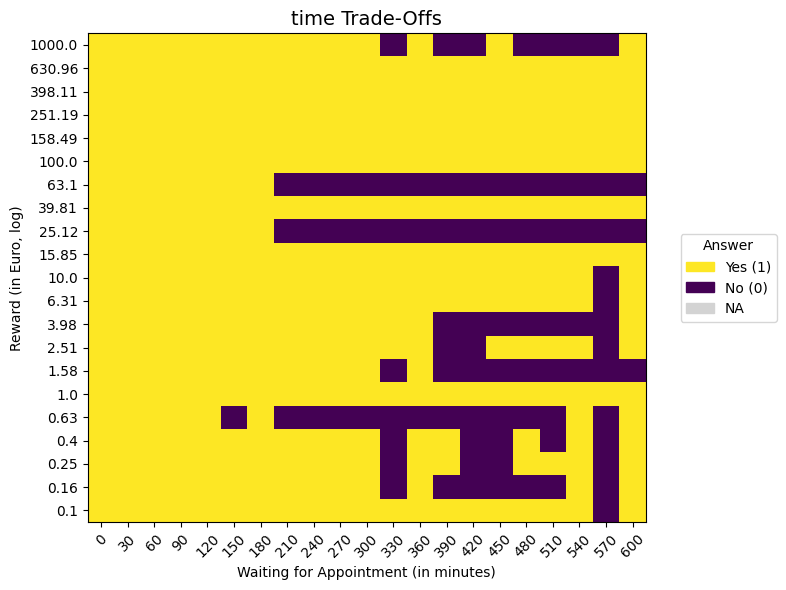

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = df_time
pivot = df.pivot(index="reward_euros", columns="quant_minutes", values="answer_num")

# --- Plot heatmap ---
plt.figure(figsize=(8, 6))
im = plt.imshow(pivot, aspect="auto", cmap="viridis", origin="lower")

plt.xticks(ticks=range(len(pivot.columns)), labels=[f"{c}" for c in pivot.columns], rotation=45)
plt.yticks(ticks=range(len(pivot.index)), labels=pivot.index)

plt.xlabel("Waiting for Appointment (in minutes)")
plt.ylabel("Reward (in Euro, log)")
plt.title(f"{PROMPT_NAME} Trade-Offs", fontsize=14)

# --- Custom legend outside the plot ---
yes_patch = mpatches.Patch(color=plt.cm.viridis(1.0), label="Yes (1)")
no_patch = mpatches.Patch(color=plt.cm.viridis(0.0), label="No (0)")
na_patch = mpatches.Patch(color="lightgrey", label="NA")

plt.legend(
    handles=[yes_patch, no_patch, na_patch],
    title="Answer",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5)
)

plt.tight_layout()

save_path = os.path.join("/teamspace/studios/this_studio/MATS/chats", 
                         f"llama3.2-3bI_{PROMPT_NAME}_{QUANTITY_N}x{MONEY_N}.png")

os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Chart saved to {save_path}")

plt.show()


# analysis

In [ ]:
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

27

In [3]:
import functools
import sys
from pathlib import Path
from typing import Callable

import circuitsvis as cv
import einops
import numpy as np
import torch as t
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import display
from jaxtyping import Float, Int
from torch import Tensor
from tqdm import tqdm
from transformer_lens import (
    ActivationCache,
    FactoredMatrix,
    HookedTransformer,
    HookedTransformerConfig,
    utils,
)
from neel_plotly import *

model: HookedTransformer = HookedTransformer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct", device='cuda')

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.2-3B-Instruct into HookedTransformer


In [6]:
prompt = """
Answer with one word. Do you accept compensation of 100.00 euros for waiting 330 minutes for food?
"""

# prompt_yesish = """
# Answer with one word. Do you accept compensation of 10.00 euros for waiting 360 minutes for food?
# """

In [7]:
from transformer_lens.utils import test_prompt

# Test the model with a prompt
test_prompt(
    prompt,
    "No",
    model,
    prepend_space_to_answer=False,
)

# test_prompt(
#     prompt_yesish,
#     "Yes",
#     model,
#     prepend_space_to_answer=False,
# )

Tokenized prompt: ['<|begin_of_text|>', '\n', 'Answer', ' with', ' one', ' word', '.', ' Do', ' you', ' accept', ' compensation', ' of', ' ', '100', '.', '00', ' euros', ' for', ' waiting', ' ', '330', ' minutes', ' for', ' food', '?\n']
Tokenized answer: ['No']


Performance on answer token:
Rank: 0        Logit: 14.73 Prob: 21.29% Token: |No|

Top 0th token. Logit: 14.73 Prob: 21.29% Token: |No|
Top 1th token. Logit: 14.57 Prob: 18.11% Token: |Yes|
Top 2th token. Logit: 14.27 Prob: 13.45% Token: |Si|
Top 3th token. Logit: 12.89 Prob:  3.36% Token: |Ja|
Top 4th token. Logit: 12.62 Prob:  2.57% Token: |S|
Top 5th token. Logit: 12.22 Prob:  1.73% Token: |Ne|
Top 6th token. Logit: 12.22 Prob:  1.73% Token: |no|
Top 7th token. Logit: 11.96 Prob:  1.34% Token: | Si|
Top 8th token. Logit: 11.90 Prob:  1.25% Token: |Do|
Top 9th token. Logit: 11.51 Prob:  0.85% Token: | Ja|


Ranks of the answer tokens: [('No', 0)]

In [8]:
# 100 euros & 330 mins

# 1. Run the model and cache everything
# prompt = """
# Answer with one word. Do you accept compensation of 100.00 euros for waiting 330 minutes for food?
# """

# forward pass with cache
logits, cache = model.run_with_cache(prompt)

# convert to tokens
tokens = model.to_str_tokens(prompt)
print("Tokens:", tokens)
print("Logits shape:", logits.shape)

Tokens: ['<|begin_of_text|>', '\n', 'Answer', ' with', ' one', ' word', '.', ' Do', ' you', ' accept', ' compensation', ' of', ' ', '100', '.', '00', ' euros', ' for', ' waiting', ' ', '330', ' minutes', ' for', ' food', '?\n']
Logits shape: torch.Size([1, 25, 128256])


In [9]:
# 2. look at next-token distribution
# take logits at the last position
last_logits = logits[0, -1, :]  # shape [vocab]
probs = torch.softmax(last_logits, dim=-1)

# check probabilities for Yes/No
yes_id = model.to_single_token("Yes")
no_id  = model.to_single_token("No")

print("P(Yes):", probs[yes_id].item())
print("P(No): ", probs[no_id].item())

# top 5 most probable next tokens
topk = torch.topk(probs, k=5)
top_ids = topk.indices.tolist()
top_probs = topk.values.tolist()

print("\nTop 5 next tokens:")
for tid, p in zip(top_ids, top_probs):
    token_str = model.to_string(tid)
    print(f"{token_str!r} : {p:.4f}")


P(Yes): 0.18107393383979797
P(No):  0.2129419445991516

Top 5 next tokens:
'No' : 0.2129
'Yes' : 0.1811
'Si' : 0.1345
'Ja' : 0.0336
'S' : 0.0257


In [12]:
# # Vis all layers
# import matplotlib.pyplot as plt

# yes_probs, no_probs = [], []
# for layer in range(model.cfg.n_layers):
#     hidden = cache[f"blocks.{layer}.hook_resid_post"][0, -1, :]
#     logits_layer = model.unembed(model.ln_final(hidden))
#     probs_layer = torch.softmax(logits_layer, dim=-1)
#     yes_probs.append(probs_layer[yes_id].item())
#     no_probs.append(probs_layer[no_id].item())

# plt.plot(yes_probs, label="Yes")
# plt.plot(no_probs, label="No")
# plt.xlabel("Layer")
# plt.ylabel("Probability")
# plt.title("Yes vs No probabilities across layers")
# plt.legend()
# plt.show()


In [13]:
tokens = model.to_tokens(prompt)


# Run model with cache
logits, cache = model.run_with_cache(tokens)

# Get Yes and No tokens
yes_token = model.to_single_token("Yes")
no_token = model.to_single_token("No")

# Get residual stream decomposition
decomposed_resid, labels = cache.get_full_resid_decomposition(
    expand_neurons=False, 
    pos_slice=-1,  # Last position
    return_labels=True
)

# Apply layer norm
decomposed_resid = cache.apply_ln_to_stack(decomposed_resid, pos_slice=-1)
print(f"Decomposed residual shape: {decomposed_resid.shape}")

# Get unembedding vectors for Yes and No
yes_unembed = model.W_U[:, yes_token]
no_unembed = model.W_U[:, no_token]

# Calculate logit difference (Yes - No)
logit_diff = yes_unembed - no_unembed

# Calculate direct logit attribution for each component
dla = einops.einsum(
    decomposed_resid, 
    logit_diff, 
    "component batch d_model, d_model -> component batch"
)

# # Since we have only one prompt, we can squeeze the batch dimension
# dla_single = dla[:, 0]  # Shape: [component]

# # Plot the results
# line(
#     dla_single, 
#     x=labels, 
#     title="Direct Logit Attribution: Yes vs No", 
#     xaxis="Component",
#     yaxis="Logit Difference (Yes - No)"
# )

# Since we have only one prompt, we can squeeze the batch dimension
dla_single = dla[:, 0]  # Shape: [component]

# Filter to only show layer 24 onwards
layer_24_start_idx = None
for i, label in enumerate(labels):
    if "L24" in label:
        layer_24_start_idx = i
        break

if layer_24_start_idx is not None:
    dla_filtered = dla_single[layer_24_start_idx:]
    labels_filtered = labels[layer_24_start_idx:]
    
    # Plot the results (layer 24 onwards only)
    line(
        dla_filtered, 
        x=labels_filtered, 
        title="Direct Logit Attribution: Logit Difference (Yes - No) (Layer 24+)", 
        xaxis="Component",
        yaxis="Logit Difference (Yes - No)"
    )
    
    print(f"Showing {len(dla_filtered)} components from layer 24 onwards")
else:
    # Fallback to show all if layer 24 not found
    line(
        dla_single, 
        x=labels, 
        title="Direct Logit Attribution: Yes vs No", 
        xaxis="Component",
        yaxis="Logit Difference (Yes - No)"
    )
    print("Layer 24 not found, showing all components")

# Optional: Show the actual logit values for Yes and No
final_logits = logits[0, -1, :]  # Last position, single batch
yes_logit = final_logits[yes_token].item()
no_logit = final_logits[no_token].item()
print(f"Final Yes logit: {yes_logit:.3f}")
print(f"Final No logit: {no_logit:.3f}")
print(f"Logit difference (Yes - No): {yes_logit - no_logit:.3f}")
print(f"Sum of DLA components: {dla_single.sum().item():.3f}")

# Optional: Show top contributing components from layer 24 onwards
if layer_24_start_idx is not None:
    top_k = 10
    top_indices = torch.topk(dla_filtered, k=min(top_k, len(dla_filtered))).indices
    print(f"\nTop {min(top_k, len(dla_filtered))} components favoring Yes (Layer 24+):")
    for i, idx in enumerate(top_indices):
        print(f"{i+1}. {labels_filtered[idx]}: {dla_filtered[idx].item():.3f}")

    bottom_indices = torch.topk(dla_filtered, k=min(top_k, len(dla_filtered)), largest=False).indices
    print(f"\nTop {min(top_k, len(dla_filtered))} components favoring No (Layer 24+):")
    for i, idx in enumerate(bottom_indices):
        print(f"{i+1}. {labels_filtered[idx]}: {dla_filtered[idx].item():.3f}")
else:
    top_k = 10
    top_indices = torch.topk(dla_single, k=top_k).indices
    print(f"\nTop {top_k} components favoring Yes:")
    for i, idx in enumerate(top_indices):
        print(f"{i+1}. {labels[idx]}: {dla_single[idx].item():.3f}")

    bottom_indices = torch.topk(dla_single, k=top_k, largest=False).indices
    print(f"\nTop {top_k} components favoring No:")
    for i, idx in enumerate(bottom_indices):
        print(f"{i+1}. {labels[idx]}: {dla_single[idx].item():.3f}")

Tried to stack head results when they weren't cached. Computing head results now
Decomposed residual shape: torch.Size([702, 1, 3072])


Showing 126 components from layer 24 onwards
Final Yes logit: 14.569
Final No logit: 14.731
Logit difference (Yes - No): -0.162
Sum of DLA components: -0.162

Top 10 components favoring Yes (Layer 24+):
1. 19_mlp_out: 4.853
2. 22_mlp_out: 3.422
3. 15_mlp_out: 0.543
4. L26H0: 0.511
5. 14_mlp_out: 0.498
6. L27H11: 0.321
7. 17_mlp_out: 0.316
8. L27H7: 0.279
9. 16_mlp_out: 0.249
10. L26H18: 0.226

Top 10 components favoring No (Layer 24+):
1. 21_mlp_out: -7.487
2. 25_mlp_out: -3.110
3. 26_mlp_out: -0.601
4. 18_mlp_out: -0.418
5. L26H1: -0.404
6. 24_mlp_out: -0.380
7. L26H2: -0.287
8. L27H2: -0.286
9. 8_mlp_out: -0.189
10. 11_mlp_out: -0.134


In [14]:
# Optional: Show the actual logit values for Yes and No
final_logits = logits[0, -1, :]  # Last position, single batch
yes_logit = final_logits[yes_token].item()
no_logit = final_logits[no_token].item()
print(f"Final Yes logit: {yes_logit:.3f}")
print(f"Final No logit: {no_logit:.3f}")
print(f"Logit difference (Yes - No): {yes_logit - no_logit:.3f}")
print(f"Sum of DLA components: {dla_single.sum().item():.3f}")

# Plot Yes vs No probabilities across layers
yes_probs, no_probs = [], []
layer_numbers = []

for layer in range(model.cfg.n_layers):
    hidden = cache[f"blocks.{layer}.hook_resid_post"][0, -1, :]
    logits_layer = model.unembed(model.ln_final(hidden))
    probs_layer = torch.softmax(logits_layer, dim=-1)
    yes_probs.append(probs_layer[yes_token].item())
    no_probs.append(probs_layer[no_token].item())
    layer_numbers.append(layer)

# Create probability plot using neel_plotly
import numpy as np
prob_data = np.stack([yes_probs, no_probs], axis=0)  # Shape: [2, n_layers]

line(
    prob_data, 
    x=layer_numbers,
    title="Yes vs No Probabilities Across Layers",
    xaxis="Layer", 
    yaxis="Probability",
    line_labels=["Yes", "No"]
)

Final Yes logit: 14.569
Final No logit: 14.731
Logit difference (Yes - No): -0.162
Sum of DLA components: -0.162


In [35]:
model

HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (ln1): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): GroupedQueryAttention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_att

In [36]:
prompt

'\nAnswer with one word. Do you accept compensation of 100.00 euros for waiting 330 minutes for food?\n'

In [36]:
# Optional: Show the actual logit values for Yes and No
final_logits = logits[0, -1, :]  # Last position, single batch
yes_logit = final_logits[yes_token].item()
no_logit = final_logits[no_token].item()
print(f"Final Yes logit: {yes_logit:.3f}")
print(f"Final No logit: {no_logit:.3f}")
print(f"Logit difference (Yes - No): {yes_logit - no_logit:.3f}")
print(f"Sum of DLA components: {dla_single.sum().item():.3f}")

# Plot Yes vs No probabilities across layers
yes_probs, no_probs = [], []
layer_numbers = []

for layer in range(model.cfg.n_layers):
    hidden = cache[f"blocks.{layer}.hook_resid_post"][0, -1, :]
    logits_layer = model.unembed(model.ln_final(hidden))
    probs_layer = torch.softmax(logits_layer, dim=-1)
    yes_probs.append(probs_layer[yes_token].item())
    no_probs.append(probs_layer[no_token].item())
    layer_numbers.append(layer)

# Create probability plot using neel_plotly
import numpy as np
prob_data = np.stack([yes_probs, no_probs], axis=0)  # Shape: [2, n_layers]

line(
    prob_data, 
    x=layer_numbers,
    title="Yes vs No Probabilities Across Layers",
    xaxis="Layer", 
    yaxis="Probability",
    line_labels=["Yes", "No"]
)

Final Yes logit: 14.569
Final No logit: 14.731
Logit difference (Yes - No): -0.162
Sum of DLA components: -0.162


In [37]:
model

HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (ln1): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): GroupedQueryAttention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_att

In [38]:
# Plot the results
line(
    dla_single, 
    x=labels, 
    title="Direct Logit Attribution: Logit Difference (Yes - No)", 
    xaxis="Component",
    yaxis="Logit Difference (Yes - No)"
)

In [26]:
# Get residual stream decomposition
decomposed_resid, labels = cache.get_full_resid_decomposition(
    expand_neurons=False, 
    pos_slice=-1,  # Last position
    return_labels=True
)

# Apply layer norm
decomposed_resid = cache.apply_ln_to_stack(decomposed_resid, pos_slice=-1)
print(f"Decomposed residual shape: {decomposed_resid.shape}")

# Get unembedding vectors for Yes and No separately
yes_unembed = model.W_U[:, yes_token]
no_unembed = model.W_U[:, no_token]

# Calculate direct logit attribution for each component - SEPARATELY for each token
yes_dla = einops.einsum(
    decomposed_resid, 
    yes_unembed, 
    "component batch d_model, d_model -> component batch"
)

no_dla = einops.einsum(
    decomposed_resid, 
    no_unembed, 
    "component batch d_model, d_model -> component batch"
)

# Since we have only one prompt, squeeze the batch dimension
yes_dla_single = yes_dla[:, 0]  # Shape: [component]
no_dla_single = no_dla[:, 0]    # Shape: [component]

# Filter to only show layer 24 onwards
layer_24_start_idx = None
for i, label in enumerate(labels):
    if "L21" in label:
        layer_24_start_idx = i
        break

if layer_24_start_idx is not None:
    yes_dla_filtered = yes_dla_single[layer_24_start_idx:]
    no_dla_filtered = no_dla_single[layer_24_start_idx:]
    labels_filtered = labels[layer_24_start_idx:]
    
    # Plot both logit attributions on the same plot
    attributions_combined = t.stack([yes_dla_filtered, no_dla_filtered], dim=0)  # Shape: [2, components]
    
    line(
        attributions_combined, 
        x=labels_filtered, 
        title="Direct Logit Attribution: Yes and No Tokens (Layer 23+)", 
        xaxis="Component",
        yaxis="Logit Attribution",
        line_labels=["Yes", "No"]
    )
    
    print(f"Showing {len(yes_dla_filtered)} components from layer 27 onwards")
else:
    # Fallback to show all if layer 24 not found
    attributions_combined = t.stack([yes_dla_single, no_dla_single], dim=0)
    
    line(
        attributions_combined, 
        x=labels, 
        title="Direct Logit Attribution: Yes and No Tokens", 
        xaxis="Component",
        yaxis="Logit Attribution",
        line_labels=["Yes", "No"]
    )
    print("Layer 24 not found, showing all components")

# Optional: Show the actual logit values for Yes and No
final_logits = logits[0, -1, :]  # Last position, single batch
yes_logit = final_logits[yes_token].item()
no_logit = final_logits[no_token].item()
print(f"Final Yes logit: {yes_logit:.3f}")
print(f"Final No logit: {no_logit:.3f}")
print(f"Logit difference (Yes - No): {yes_logit - no_logit:.3f}")
print(f"Sum of Yes DLA components: {yes_dla_single.sum().item():.3f}")
print(f"Sum of No DLA components: {no_dla_single.sum().item():.3f}")

# Optional: Show top contributing components from layer 24 onwards
# if layer_24_start_idx is not None:
#     top_k = 3
    
#     # Top components for Yes
#     yes_top_indices = t.topk(yes_dla_filtered, k=min(top_k, len(yes_dla_filtered))).indices
#     print(f"\nTop {min(top_k, len(yes_dla_filtered))} components contributing to Yes:")
#     for i, idx in enumerate(yes_top_indices):
#         print(f"{i+1}. {labels_filtered[idx]}: {yes_dla_filtered[idx].item():.3f}")
    
#     # Top components for No
#     no_top_indices = t.topk(no_dla_filtered, k=min(top_k, len(no_dla_filtered))).indices
#     print(f"\nTop {min(top_k, len(no_dla_filtered))} components contributing to No:")
#     for i, idx in enumerate(no_top_indices):
#         print(f"{i+1}. {labels_filtered[idx]}: {no_dla_filtered[idx].item():.3f}")

top_k = 3

# Top components for Yes
yes_top_indices = t.topk(yes_dla_single, k=top_k).indices
print(f"\nTop {top_k} components contributing to 'Yes' (logits):")
for i, idx in enumerate(yes_top_indices):
    print(f"{i+1}. {labels[idx]}: {yes_dla_single[idx].item():.3f}")

# Top components for No
no_top_indices = t.topk(no_dla_single, k=top_k).indices
print(f"\nTop {top_k} components contributing to 'No' (logits):")
for i, idx in enumerate(no_top_indices):
    print(f"{i+1}. {labels[idx]}: {no_dla_single[idx].item():.3f}")

Decomposed residual shape: torch.Size([702, 1, 3072])


Showing 198 components from layer 27 onwards
Final Yes logit: 14.569
Final No logit: 14.731
Logit difference (Yes - No): -0.162
Sum of Yes DLA components: 14.569
Sum of No DLA components: 14.731

Top 3 components contributing to 'Yes' (logits):
1. 19_mlp_out: 6.159
2. 27_mlp_out: 3.394
3. 15_mlp_out: 0.967

Top 3 components contributing to 'No' (logits):
1. 21_mlp_out: 6.125
2. 27_mlp_out: 3.379
3. 25_mlp_out: 1.985


In [27]:
import torch
import torch.nn.functional as F
import numpy as np
import plotly.express as px

# Assumes you already ran:
# logits, cache = model.run_with_cache(prompt)

device = logits.device
n_layers = model.cfg.n_layers
n_heads  = model.cfg.n_heads

# Get token ids for "Yes"/"No" (try both w/ and w/o leading space)
def _tok_id(s):
    try:
        tid = model.to_single_token(s)
        return tid
    except Exception:
        return None

yes_id = _tok_id("Yes")
no_id  = _tok_id("No")
assert yes_id is not None and no_id is not None, "Couldn't find Yes/No token IDs."

# Unembed direction for Yes vs No: [d_model]
W_U = model.W_U.to(device)                       # [d_model, vocab]
yes_no_dir = W_U[:, yes_id] - W_U[:, no_id]      # [d_model]

# Heatmap array: layers x heads
head_attr = torch.zeros((n_layers, n_heads), device=device)

with torch.no_grad():
    for L in range(n_layers):
        # Head outputs at last token BEFORE W_O: hook_z → [batch, seq, n_heads, d_head]
        # We want batch=0, last position
        z = cache[f"blocks.{L}.attn.hook_z"][0, -1, :, :]            # [n_heads, d_head]

        # Per-head output projection matrices W_O[L]: [n_heads, d_head, d_model]
        W_O_L = model.W_O[L].to(device)

        # Map each head's z through its W_O to get residual contribution: [n_heads, d_model]
        # contrib[h] = z[h] @ W_O_L[h]
        contrib = torch.einsum("hd,hdm->hm", z, W_O_L)               # [n_heads, d_model]

        # Logit attribution for Yes-No: (contrib · (W_U_yes - W_U_no)) per head → [n_heads]
        head_attr[L] = contrib @ yes_no_dir                           # [n_heads]

# To CPU / numpy for Plotlya
attr_np = head_attr.detach().float().cpu().numpy()

# Plot as heatmap (layers × heads)
fig = px.imshow(
    attr_np,
    x=[f"H{h}" for h in range(n_heads)],
    y=[f"L{l}" for l in range(n_layers)],
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0.0,
    labels=dict(x="Attention head", y="Layer", color="Logit attribution diff."),
    title="Logit attribution difference (Yes-No)",
)

fig.show()


In [ ]:
# # head_attr: [n_layers, n_heads] (Yes−No logit contributions)

# # flatten with indices
# flat = []
# for L in range(n_layers):
#     for H in range(n_heads):
#         val = attr_np[L, H]   # from the numpy array
#         flat.append(((L, H), val))

# # sort by absolute magnitude (strongest contributors)
# flat_sorted = sorted(flat, key=lambda x: abs(x[1]), reverse=True)

# print("Top 5 heads by |Yes−No attribution|:")
# for (L, H), val in flat_sorted[:5]:
#     direction = "Yes" if val > 0 else "No"
#     print(f"Layer {L}, Head {H} : {val:.4f} (pushes toward {direction})")


Top 5 heads by |Yes−No attribution|:
Layer 26, Head 0 : 0.4438 (pushes toward Yes)
Layer 23, Head 17 : 0.3728 (pushes toward Yes)
Layer 26, Head 1 : -0.3507 (pushes toward No)
Layer 23, Head 13 : 0.3040 (pushes toward Yes)
Layer 27, Head 11 : 0.2784 (pushes toward Yes)


In [ ]:
# import torch
# from transformer_lens import HookedTransformer

# # (assumes you already have `model`, `prompt`, `yes_id`, `no_id`)

# # --- 1. Baseline run ---
# logits_base, _ = model.run_with_cache(prompt)
# last_logits_base = logits_base[0, -1, :]
# probs_base = torch.softmax(last_logits_base, dim=-1)
# p_yes_base = probs_base[yes_id].item()
# p_no_base  = probs_base[no_id].item()

# print(f"Baseline P(Yes): {p_yes_base:.4f}, P(No): {p_no_base:.4f}")


# # --- 2. Ablation hook for Layer 26, Head 0 ---
# def zero_head(z, hook):
#     # z: [batch, seq, n_heads, d_head]
#     z[:, :, 0, :] = 0     # zero out head 0 only
#     return z

# with model.hooks(fwd_hooks=[(f"blocks.27.attn.hook_z", zero_head)]):
#     logits_abl, _ = model.run_with_cache(prompt)

# last_logits_abl = logits_abl[0, -1, :]
# probs_abl = torch.softmax(last_logits_abl, dim=-1)
# p_yes_abl = probs_abl[yes_id].item()
# p_no_abl  = probs_abl[no_id].item()

# print(f"Ablated P(Yes): {p_yes_abl:.4f}, P(No): {p_no_abl:.4f}")


# # --- 3. Compare ---
# print(f"ΔYes = {p_yes_base - p_yes_abl:.4f}, ΔNo = {p_no_base - p_no_abl:.4f}")


Baseline P(Yes): 0.1811, P(No): 0.2129
Ablated P(Yes): 0.1805, P(No): 0.2223
ΔYes = 0.0006, ΔNo = -0.0094


In [29]:
flat = []
for L in range(model.cfg.n_layers):
    for H in range(model.cfg.n_heads):
        val = attr_np[L, H]   # your attribution matrix
        flat.append(((L, H), val))

yes_pushers = sorted(flat, key=lambda x: x[1], reverse=True)  # biggest positive
no_pushers  = sorted(flat, key=lambda x: x[1])                # biggest negative

print("Top 5 Yes-pushers:")
for (L, H), val in yes_pushers[:5]:
    print(f"Layer {L}, Head {H} : {val:.4f}")

print("\nTop 5 No-pushers:")
for (L, H), val in no_pushers[:5]:
    print(f"Layer {L}, Head {H} : {val:.4f}")


Top 5 Yes-pushers:
Layer 26, Head 0 : 0.4438
Layer 23, Head 17 : 0.3728
Layer 23, Head 13 : 0.3040
Layer 27, Head 11 : 0.2784
Layer 27, Head 7 : 0.2426

Top 5 No-pushers:
Layer 26, Head 1 : -0.3507
Layer 26, Head 2 : -0.2487
Layer 27, Head 2 : -0.2478
Layer 21, Head 0 : -0.1562
Layer 17, Head 8 : -0.1197


In [ ]:
# import torch
# import torch.nn.functional as F

# # ------- common utilities -------

# def get_yes_no_ids(model):
#     """Return token ids for Yes / No (try with and without leading space)."""
#     def _id(s):
#         try:
#             return model.to_single_token(s)
#         except Exception:
#             return None
#     yes = _id("Yes")
#     no  = _id("No")
#     assert yes is not None and no is not None, "Could not resolve Yes/No token IDs."
#     return yes, no

# def get_yes_no_probs(model, prompt, yes_id, no_id):
#     """Run forward pass and return P(Yes), P(No) at the last position."""
#     logits, _ = model.run_with_cache(prompt)
#     last_logits = logits[0, -1, :]
#     probs = F.softmax(last_logits, dim=-1)
#     return probs[yes_id].item(), probs[no_id].item()

# # ============================================================
# # 1) CAUSAL ABLATION: zero a single head and re-evaluate
# # ============================================================

# def ablate_head_once(model, prompt, L, H, yes_id=None, no_id=None):
#     """
#     Zero the output of attention head (L, H) for the entire sequence and
#     return (P_yes, P_no) after ablation.
#     """
#     if yes_id is None or no_id is None:
#         yes_id, no_id = get_yes_no_ids(model)

#     def zero_head(z, hook):
#         # z: [batch, seq, n_heads, d_head]
#         z[:, :, H, :] = 0
#         return z

#     with model.hooks([(f"blocks.{L}.attn.hook_z", zero_head)]):
#         logits_abl, _ = model.run_with_cache(prompt)
#     last_logits = logits_abl[0, -1, :]
#     probs = F.softmax(last_logits, dim=-1)
#     return probs[yes_id].item(), probs[no_id].item()

# def causal_effect_of_head(model, prompt, L, H):
#     """
#     Report baseline vs ablated probabilities and deltas for head (L,H).
#     Positive ΔYes (baseline - ablated) => head is a Yes-pusher.
#     Positive ΔNo  => head is a No-pusher.
#     """
#     yes_id, no_id = get_yes_no_ids(model)
#     p_yes_base, p_no_base = get_yes_no_probs(model, prompt, yes_id, no_id)
#     p_yes_abl,  p_no_abl  = ablate_head_once(model, prompt, L, H, yes_id, no_id)

#     d_yes = p_yes_base - p_yes_abl
#     d_no  = p_no_base  - p_no_abl

#     print(f"[Head L{L} H{H}]  Baseline  P(Yes)={p_yes_base:.4f}  P(No)={p_no_base:.4f}")
#     print(f"[Head L{L} H{H}]  Ablated   P(Yes)={p_yes_abl:.4f}   P(No)={p_no_abl:.4f}")
#     print(f"[Head L{L} H{H}]  ΔYes={d_yes:+.4f}  ΔNo={d_no:+.4f}  "
#           f"({'Yes-pusher' if d_yes>0 else 'No-pusher' if d_no>0 else 'other'})")
#     return dict(p_yes_base=p_yes_base, p_no_base=p_no_base,
#                 p_yes_abl=p_yes_abl, p_no_abl=p_no_abl,
#                 delta_yes=d_yes, delta_no=d_no)

# # ============================================================
# # 2) ACTIVATION PATCHING: copy a head’s activations
# #    from a source prompt into a target prompt
# # ============================================================

# def patch_head_between_prompts(
#     model,
#     prompt_src,            # where the model tends to answer "No" (or whatever behavior you want to transfer)
#     prompt_tgt,            # where you'd like to see the effect
#     L, H,
#     mode="last",           # "last" -> patch only last-token query step; "all" -> patch all positions up to min length
# ):
#     """
#     Activation patching of head (L,H):
#       1) Run with cache on source and target.
#       2) During a re-run on the target, overwrite head (L,H) 'hook_z' with the source values.

#     Returns:
#       dict with baseline & patched P(Yes/No) on the target prompt and the deltas.
#     """
#     yes_id, no_id = get_yes_no_ids(model)

#     # 1) Baseline target run
#     logits_tgt_base, cache_tgt_base = model.run_with_cache(prompt_tgt)
#     last_logits_tgt = logits_tgt_base[0, -1, :]
#     probs_tgt_base = F.softmax(last_logits_tgt, dim=-1)
#     p_yes_tgt_base, p_no_tgt_base = probs_tgt_base[yes_id].item(), probs_tgt_base[no_id].item()

#     # 2) Source run (to get the head activations we will patch in)
#     _, cache_src = model.run_with_cache(prompt_src)
#     z_src = cache_src[f"blocks.{L}.attn.hook_z"]    # [batch=1, seq_src, n_heads, d_head]

#     # 3) Hook that overwrites target head with source head
#     def patch_z(z_tgt, hook):
#         # z_tgt: [batch, seq_tgt, n_heads, d_head]
#         if mode == "last":
#             # use only the last position (query step for next token)
#             z_tgt[:, -1, H, :] = z_src[:, -1, H, :].to(z_tgt.dtype).to(z_tgt.device)
#         elif mode == "all":
#             # align up to min length
#             seq_src = z_src.shape[1]
#             seq_tgt = z_tgt.shape[1]
#             m = min(seq_src, seq_tgt)
#             z_tgt[:, :m, H, :] = z_src[:, :m, H, :].to(z_tgt.dtype).to(z_tgt.device)
#         else:
#             raise ValueError("mode must be 'last' or 'all'")
#         return z_tgt

#     with model.hooks([(f"blocks.{L}.attn.hook_z", patch_z)]):
#         logits_tgt_patched, _ = model.run_with_cache(prompt_tgt)

#     last_logits_patched = logits_tgt_patched[0, -1, :]
#     probs_tgt_patched = F.softmax(last_logits_patched, dim=-1)
#     p_yes_tgt_patched = probs_tgt_patched[yes_id].item()
#     p_no_tgt_patched  = probs_tgt_patched[no_id].item()

#     print(f"[Patch L{L} H{H} | mode={mode}]  Target baseline  P(Yes)={p_yes_tgt_base:.4f}  P(No)={p_no_tgt_base:.4f}")
#     print(f"[Patch L{L} H{H} | mode={mode}]  Target patched   P(Yes)={p_yes_tgt_patched:.4f}  P(No)={p_no_tgt_patched:.4f}")
#     print(f"[Patch L{L} H{H} | mode={mode}]  ΔYes={p_yes_tgt_patched-p_yes_tgt_base:+.4f}  "
#           f"ΔNo={p_no_tgt_patched-p_no_tgt_base:+.4f}")

#     return dict(
#         p_yes_base=p_yes_tgt_base, p_no_base=p_no_tgt_base,
#         p_yes_patched=p_yes_tgt_patched, p_no_patched=p_no_tgt_patched,
#         delta_yes=p_yes_tgt_patched-p_yes_tgt_base,
#         delta_no=p_no_tgt_patched-p_no_tgt_base,
#     )


In [30]:
# # Example prompts (choose ones where you observe different labels) 
# prompt_noish = """
# Answer with one word. Do you accept compensation of 10.00 euros for waiting 330 minutes for food?
# """

# prompt_yesish = """
# Answer with one word. Do you accept compensation of 10.00 euros for waiting 360 minutes for food?
# """


# # 1) Causal ablation of a suspected No-pusher head
# _ = causal_effect_of_head(model, prompt_noish, L=26, H=1)

# # 2) Activation patching (transfer head (26,0) from 'No' prompt into a 'Yes' prompt)
# _ = patch_head_between_prompts(
#     model,
#     prompt_src=prompt_noish,   # where it tends to say "No"
#     prompt_tgt=prompt_yesish,  # where you'd expect "Yes"
#     L=26, H=1,
#     mode="last",               # or "all"
# )


In [50]:
import torch
import torch.nn.functional as F

def mean_ablate_head(model, prompt, L, H, yes_id=None, no_id=None, mode="last"):
    """
    Replace head (L,H) activations with their mean value (across sequence positions).
    mode = "last" -> patch only the last token.
    mode = "all"  -> patch all positions in the sequence.
    Returns baseline and mean-ablated P(Yes)/P(No).
    """
    # resolve token IDs
    def _id(s):
        try: return model.to_single_token(s)
        except Exception: return None
    if yes_id is None or no_id is None:
        yes_id = _id("Yes")
        no_id  = _id("No")
    assert yes_id is not None and no_id is not None

    # baseline
    logits_base, cache_base = model.run_with_cache(prompt)
    last_logits = logits_base[0, -1, :]
    probs_base = F.softmax(last_logits, dim=-1)
    p_yes_base, p_no_base = probs_base[yes_id].item(), probs_base[no_id].item()

    # compute mean z for this head across the sequence
    z_all = cache_base[f"blocks.{L}.attn.hook_z"][0, :, H, :]   # [seq, d_head]
    z_mean = z_all.mean(dim=0, keepdim=True)                    # [1, d_head]

    # patch hook
    def patch_to_mean(z, hook):
        # z: [batch, seq, n_heads, d_head]
        if mode == "last":
            z[:, -1, H, :] = z_mean.to(z.dtype).to(z.device)
        elif mode == "all":
            z[:, :, H, :] = z_mean.to(z.dtype).to(z.device)
        return z

    with model.hooks([(f"blocks.{L}.attn.hook_z", patch_to_mean)]):
        logits_ablate, _ = model.run_with_cache(prompt)

    last_logits_ablate = logits_ablate[0, -1, :]
    probs_ablate = F.softmax(last_logits_ablate, dim=-1)
    p_yes_ablate, p_no_ablate = probs_ablate[yes_id].item(), probs_ablate[no_id].item()

    print(f"[Mean-ablation L{L}H{H}]")
    print(f"Baseline  P(Yes)={p_yes_base:.4f}, P(No)={p_no_base:.4f}")
    print(f"Mean-abl  P(Yes)={p_yes_ablate:.4f}, P(No)={p_no_ablate:.4f}")
    print(f"ΔYes={p_yes_base-p_yes_ablate:+.4f}, ΔNo={p_no_base-p_no_ablate:+.4f}")

    return dict(
        p_yes_base=p_yes_base, p_no_base=p_no_base,
        p_yes_ablate=p_yes_ablate, p_no_ablate=p_no_ablate,
        delta_yes=p_yes_base - p_yes_ablate,
        delta_no=p_no_base  - p_no_ablate
    )

# Example: mean-ablate Layer 26, Head 1
res = mean_ablate_head(model, prompt, L=26, H=10, mode="last")


[Mean-ablation L26H10]
Baseline  P(Yes)=0.1811, P(No)=0.2129
Mean-abl  P(Yes)=0.1782, P(No)=0.2123
ΔYes=+0.0029, ΔNo=+0.0007


In [48]:
# Example: mean-ablate Layer 26, Head 1
res = mean_ablate_head(model, prompt, L=27, H=2, mode="last")

[Mean-ablation L27H2]
Baseline  P(Yes)=0.1811, P(No)=0.2129
Mean-abl  P(Yes)=0.1744, P(No)=0.1925
ΔYes=+0.0067, ΔNo=+0.0205


In [41]:
import torch
import numpy as np
from transformer_lens import HookedTransformer
from neel_plotly import *


tokens = model.to_tokens(prompt)

# Get baseline (clean) run
clean_logits, clean_cache = model.run_with_cache(tokens)
yes_token = model.to_single_token("Yes")
no_token = model.to_single_token("No")

# Get baseline probabilities
clean_probs = torch.softmax(clean_logits[0, -1, :], dim=-1)
baseline_yes_prob = clean_probs[yes_token].item()
baseline_no_prob = clean_probs[no_token].item()
baseline_logit_diff = (clean_logits[0, -1, yes_token] - clean_logits[0, -1, no_token]).item()

print(f"Baseline - Yes: {baseline_yes_prob:.3f}, No: {baseline_no_prob:.3f}")
print(f"Baseline logit difference (Yes - No): {baseline_logit_diff:.3f}")

# Function to create mean ablation hook for a specific MLP layer
def create_mlp_ablation_hook(layer_idx, clean_cache):
    """Creates a hook that replaces MLP output with its mean across sequence positions"""
    def ablation_hook(mlp_out, hook):
        # mlp_out shape: [batch, seq_len, d_model]
        # Replace with mean across sequence dimension
        mean_activation = clean_cache[f"blocks.{layer_idx}.mlp.hook_post"].mean(dim=1, keepdim=True)
        # Broadcast to all sequence positions
        mlp_out[:] = mean_activation
        return mlp_out
    return ablation_hook

# Test ablation of individual MLP layers
n_layers = model.cfg.n_layers
layer_results = []
layers_to_test = range(max(0, n_layers-15), n_layers)  # Test last 15 layers

print(f"\nTesting ablation of MLP layers {min(layers_to_test)} to {max(layers_to_test)}:")
print("-" * 60)

for layer_idx in layers_to_test:
    # Create the ablation hook
    hook_fn = create_mlp_ablation_hook(layer_idx, clean_cache)
    
    # Run with ablation
    with model.hooks(fwd_hooks=[(f"blocks.{layer_idx}.mlp.hook_post", hook_fn)]):
        ablated_logits = model(tokens)
    
    # Calculate results
    ablated_probs = torch.softmax(ablated_logits[0, -1, :], dim=-1)
    ablated_yes_prob = ablated_probs[yes_token].item()
    ablated_no_prob = ablated_probs[no_token].item()
    ablated_logit_diff = (ablated_logits[0, -1, yes_token] - ablated_logits[0, -1, no_token]).item()
    
    # Calculate changes
    yes_prob_change = ablated_yes_prob - baseline_yes_prob
    no_prob_change = ablated_no_prob - baseline_no_prob
    logit_diff_change = ablated_logit_diff - baseline_logit_diff
    
    layer_results.append({
        'layer': layer_idx,
        'yes_prob_change': yes_prob_change,
        'no_prob_change': no_prob_change,
        'logit_diff_change': logit_diff_change,
        'ablated_yes_prob': ablated_yes_prob,
        'ablated_no_prob': ablated_no_prob
    })
    
    print(f"Layer {layer_idx:2d}: Yes Δ={yes_prob_change:+.3f}, No Δ={no_prob_change:+.3f}, "
          f"LogitDiff Δ={logit_diff_change:+.3f}")

# Convert to arrays for plotting
layers = [r['layer'] for r in layer_results]
yes_changes = [r['yes_prob_change'] for r in layer_results]
no_changes = [r['no_prob_change'] for r in layer_results]
logit_diff_changes = [r['logit_diff_change'] for r in layer_results]

# Plot probability changes
prob_changes = np.array([yes_changes, no_changes])
line(
    prob_changes,
    x=layers,
    title="Probability Changes from MLP Mean Ablation",
    xaxis="Layer",
    yaxis="Probability Change",
    line_labels=["Yes Change", "No Change"]
)

# Plot logit difference changes
line(
    logit_diff_changes,
    x=layers,
    title="Logit Difference Changes from MLP Mean Ablation",
    xaxis="Layer", 
    yaxis="Logit Difference Change (Yes - No)",
    line_labels=["Logit Diff Change"]
)

# Find most important layers
most_impactful = sorted(layer_results, key=lambda x: abs(x['logit_diff_change']), reverse=True)
print(f"\nMost impactful MLP layers (by absolute logit difference change):")
print("-" * 60)
for i, result in enumerate(most_impactful[:5]):
    print(f"{i+1}. Layer {result['layer']}: Logit diff change = {result['logit_diff_change']:+.3f}")
    print(f"   Final probs after ablation - Yes: {result['ablated_yes_prob']:.3f}, No: {result['ablated_no_prob']:.3f}")

# Test multiple layer ablation for the most impactful layers
#print(f"\nTesting simultaneous ablation of top 1 most impactful layer:")
top_3_layers = [r['layer'] for r in most_impactful[:1]]
print(f"Ablating layer: {top_3_layers}")

# Create multiple hooks
hooks = []
for layer_idx in top_3_layers:
    hook_fn = create_mlp_ablation_hook(layer_idx, clean_cache)
    hooks.append((f"blocks.{layer_idx}.mlp.hook_post", hook_fn))

# Run with multiple ablations
with model.hooks(fwd_hooks=hooks):
    multi_ablated_logits = model(tokens)

multi_ablated_probs = torch.softmax(multi_ablated_logits[0, -1, :], dim=-1)
multi_yes_prob = multi_ablated_probs[yes_token].item()
multi_no_prob = multi_ablated_probs[no_token].item()
multi_logit_diff = (multi_ablated_logits[0, -1, yes_token] - multi_ablated_logits[0, -1, no_token]).item()

print(f"Results with top 1 layer ablated:")
print(f"Yes: {baseline_yes_prob:.3f} → {multi_yes_prob:.3f} (Δ={multi_yes_prob-baseline_yes_prob:+.3f})")
print(f"No:  {baseline_no_prob:.3f} → {multi_no_prob:.3f} (Δ={multi_no_prob-baseline_no_prob:+.3f})")
print(f"Logit diff: {baseline_logit_diff:.3f} → {multi_logit_diff:.3f} (Δ={multi_logit_diff-baseline_logit_diff:+.3f})")

# Check if decision flipped
baseline_decision = "Yes" if baseline_yes_prob > baseline_no_prob else "No"
multi_ablated_decision = "Yes" if multi_yes_prob > multi_no_prob else "No"
print(f"\nDecision change: {baseline_decision} → {multi_ablated_decision}")
if baseline_decision != multi_ablated_decision:
    print("🔥 DECISION FLIPPED! These MLP layers are causally important.")
else:
    print("Decision unchanged, but probabilities shifted.")

Baseline - Yes: 0.181, No: 0.213
Baseline logit difference (Yes - No): -0.162

Testing ablation of MLP layers 13 to 27:
------------------------------------------------------------
Layer 13: Yes Δ=-0.026, No Δ=+0.154, LogitDiff Δ=-0.702
Layer 14: Yes Δ=-0.012, No Δ=+0.020, LogitDiff Δ=-0.163
Layer 15: Yes Δ=-0.032, No Δ=+0.170, LogitDiff Δ=-0.778
Layer 16: Yes Δ=+0.155, No Δ=+0.040, LogitDiff Δ=+0.446
Layer 17: Yes Δ=+0.057, No Δ=+0.036, LogitDiff Δ=+0.115
Layer 18: Yes Δ=+0.122, No Δ=+0.079, LogitDiff Δ=+0.199
Layer 19: Yes Δ=-0.132, No Δ=-0.138, LogitDiff Δ=-0.261
Layer 20: Yes Δ=-0.057, No Δ=-0.028, LogitDiff Δ=-0.236
Layer 21: Yes Δ=+0.176, No Δ=-0.186, LogitDiff Δ=+2.735
Layer 22: Yes Δ=-0.045, No Δ=+0.062, LogitDiff Δ=-0.541
Layer 23: Yes Δ=+0.067, No Δ=+0.076, LogitDiff Δ=+0.010
Layer 24: Yes Δ=+0.040, No Δ=-0.030, LogitDiff Δ=+0.351
Layer 25: Yes Δ=+0.108, No Δ=+0.038, LogitDiff Δ=+0.302
Layer 26: Yes Δ=-0.019, No Δ=-0.021, LogitDiff Δ=-0.006
Layer 27: Yes Δ=-0.097, No Δ=-0.146


Most impactful MLP layers (by absolute logit difference change):
------------------------------------------------------------
1. Layer 21: Logit diff change = +2.735
   Final probs after ablation - Yes: 0.357, No: 0.027
2. Layer 15: Logit diff change = -0.778
   Final probs after ablation - Yes: 0.150, No: 0.383
3. Layer 13: Logit diff change = -0.702
   Final probs after ablation - Yes: 0.155, No: 0.367
4. Layer 22: Logit diff change = -0.541
   Final probs after ablation - Yes: 0.136, No: 0.275
5. Layer 16: Logit diff change = +0.446
   Final probs after ablation - Yes: 0.336, No: 0.253
Ablating layer: [21]
Results with top 1 layer ablated:
Yes: 0.181 → 0.357 (Δ=+0.176)
No:  0.213 → 0.027 (Δ=-0.186)
Logit diff: -0.162 → 2.573 (Δ=+2.735)

Decision change: No → Yes
🔥 DECISION FLIPPED! These MLP layers are causally important.


In [46]:
import torch
import numpy as np
from neel_plotly import *

# SPECIFY WHICH MLP LAYER TO ABLATE HERE
LAYER_TO_ABLATE = 21  # Change this to test different layers

# Your prompt and tokens (assuming already defined)
# prompt = "..."
# tokens = model.to_tokens(prompt)

# Get baseline (clean) run
print(f"Running baseline...")
clean_logits, clean_cache = model.run_with_cache(tokens)
yes_token = model.to_single_token("Yes")
no_token = model.to_single_token("No")

# Baseline probabilities across all layers
baseline_yes_probs = []
baseline_no_probs = []
layer_numbers = []

for layer in range(model.cfg.n_layers):
    hidden = clean_cache[f"blocks.{layer}.hook_resid_post"][0, -1, :]
    logits_layer = model.unembed(model.ln_final(hidden))
    probs_layer = torch.softmax(logits_layer, dim=-1)
    baseline_yes_probs.append(probs_layer[yes_token].item())
    baseline_no_probs.append(probs_layer[no_token].item())
    layer_numbers.append(layer)

print(f"Baseline final - Yes: {baseline_yes_probs[-1]:.3f}, No: {baseline_no_probs[-1]:.3f}")

# Create mean ablation hook for the specified MLP layer
def mlp_ablation_hook(mlp_out, hook):
    """Replace MLP output with its mean across sequence positions"""
    mean_activation = clean_cache[f"blocks.{LAYER_TO_ABLATE}.mlp.hook_post"].mean(dim=1, keepdim=True)
    mlp_out[:] = mean_activation
    return mlp_out

# Run with MLP layer ablated
print(f"Running with Layer {LAYER_TO_ABLATE} MLP ablated...")
with model.hooks(fwd_hooks=[(f"blocks.{LAYER_TO_ABLATE}.mlp.hook_post", mlp_ablation_hook)]):
    ablated_logits, ablated_cache = model.run_with_cache(tokens)

# Ablated probabilities across all layers
ablated_yes_probs = []
ablated_no_probs = []

for layer in range(model.cfg.n_layers):
    hidden = ablated_cache[f"blocks.{layer}.hook_resid_post"][0, -1, :]
    logits_layer = model.unembed(model.ln_final(hidden))
    probs_layer = torch.softmax(logits_layer, dim=-1)
    ablated_yes_probs.append(probs_layer[yes_token].item())
    ablated_no_probs.append(probs_layer[no_token].item())

print(f"Ablated final - Yes: {ablated_yes_probs[-1]:.3f}, No: {ablated_no_probs[-1]:.3f}")

# Calculate probability changes
yes_changes = [ablated - baseline for ablated, baseline in zip(ablated_yes_probs, baseline_yes_probs)]
no_changes = [ablated - baseline for ablated, baseline in zip(ablated_no_probs, baseline_no_probs)]

# Create comparison plots
# 1. Baseline vs Ablated probabilities
baseline_data = np.array([baseline_yes_probs, baseline_no_probs])
ablated_data = np.array([ablated_yes_probs, ablated_no_probs])

line(
    baseline_data,
    x=layer_numbers,
    title=f"Baseline: Yes vs No Probabilities Across Layers",
    xaxis="Layer",
    yaxis="Probability",
    line_labels=["Yes (Baseline)", "No (Baseline)"]
)

line(
    ablated_data,
    x=layer_numbers,
    title=f"Ablated L{LAYER_TO_ABLATE} MLP: Yes vs No Probabilities Across Layers",
    xaxis="Layer",
    yaxis="Probability",
    line_labels=["Yes (Ablated)", "No (Ablated)"]
)

# 2. Changes due to ablation
changes_data = np.array([yes_changes, no_changes])
line(
    changes_data,
    x=layer_numbers,
    title=f"Probability Changes from Ablating L{LAYER_TO_ABLATE} MLP",
    xaxis="Layer",
    yaxis="Probability Change",
    line_labels=["Yes Change", "No Change"]
)

# 3. Combined comparison (all 4 lines)
combined_data = np.array([baseline_yes_probs, baseline_no_probs, ablated_yes_probs, ablated_no_probs])
fig = line(
    combined_data,
    x=layer_numbers,
    title=f"Baseline vs Ablated L{LAYER_TO_ABLATE} MLP: All Probabilities",
    xaxis="Layer",
    yaxis="Probability",
    line_labels=["Yes (Baseline)", "No (Baseline)", "Yes (Ablated)", "No (Ablated)"]
)

fig.add_vline(
            x=21, 
            line_dash="dash", 
            line_color="red", 
            line_width=2,
            annotation_text=f"Ablated L{21}",
            annotation_position="top"
        )

# Summary statistics
final_yes_change = yes_changes[-1]
final_no_change = no_changes[-1]
final_logit_diff_change = (ablated_logits[0, -1, yes_token] - ablated_logits[0, -1, no_token]).item() - baseline_logit_diff

print(f"\n" + "="*60)
print(f"ABLATION SUMMARY FOR LAYER {LAYER_TO_ABLATE} MLP:")
print(f"="*60)
print(f"Final Yes probability change: {final_yes_change:+.4f}")
print(f"Final No probability change:  {final_no_change:+.4f}")
print(f"Final logit diff change:      {final_logit_diff_change:+.4f}")

# Check decision flip
baseline_decision = "Yes" if baseline_yes_probs[-1] > baseline_no_probs[-1] else "No"
ablated_decision = "Yes" if ablated_yes_probs[-1] > ablated_no_probs[-1] else "No"
# print(f"Decision: {baseline_decision} → {ablated_decision}")

if baseline_decision != ablated_decision:
    print(f"\nDECISION FLIPPED! Layer {LAYER_TO_ABLATE} MLP is causally important.")
else:
    print(f"Decision unchanged.")

# Show when the biggest change occurs
max_change_layer = np.argmax(np.abs(yes_changes))
print(f"Biggest Yes probability change occurs at layer {max_change_layer}: {yes_changes[max_change_layer]:+.4f}")

Running baseline...
Baseline final - Yes: 0.181, No: 0.213
Running with Layer 21 MLP ablated...
Ablated final - Yes: 0.357, No: 0.027


AttributeError: 'NoneType' object has no attribute 'add_vline'

In [50]:
import torch
import numpy as np
from neel_plotly import *

# SPECIFY WHICH MLP LAYER TO ABLATE HERE
LAYER_TO_ABLATE = 21  # Change this to test different layers

# Your prompt and tokens (assuming already defined)
# prompt = "..."
# tokens = model.to_tokens(prompt)

# Get baseline (clean) run
print(f"Running baseline...")
clean_logits, clean_cache = model.run_with_cache(tokens)
yes_token = model.to_single_token("Yes")
no_token = model.to_single_token("No")

# Baseline probabilities across all layers
baseline_yes_probs = []
baseline_no_probs = []
layer_numbers = []

for layer in range(model.cfg.n_layers):
    hidden = clean_cache[f"blocks.{layer}.hook_resid_post"][0, -1, :]
    logits_layer = model.unembed(model.ln_final(hidden))
    probs_layer = torch.softmax(logits_layer, dim=-1)
    baseline_yes_probs.append(probs_layer[yes_token].item())
    baseline_no_probs.append(probs_layer[no_token].item())
    layer_numbers.append(layer)

print(f"Baseline final - Yes: {baseline_yes_probs[-1]:.3f}, No: {baseline_no_probs[-1]:.3f}")

# Create mean ablation hook for the specified MLP layer
def mlp_ablation_hook(mlp_out, hook):
    """Replace MLP output with its mean across sequence positions"""
    mean_activation = clean_cache[f"blocks.{LAYER_TO_ABLATE}.mlp.hook_post"].mean(dim=1, keepdim=True)
    mlp_out[:] = mean_activation
    return mlp_out

# Run with MLP layer ablated
print(f"Running with Layer {LAYER_TO_ABLATE} MLP ablated...")
with model.hooks(fwd_hooks=[(f"blocks.{LAYER_TO_ABLATE}.mlp.hook_post", mlp_ablation_hook)]):
    ablated_logits, ablated_cache = model.run_with_cache(tokens)

# Ablated probabilities across all layers
ablated_yes_probs = []
ablated_no_probs = []

for layer in range(model.cfg.n_layers):
    hidden = ablated_cache[f"blocks.{layer}.hook_resid_post"][0, -1, :]
    logits_layer = model.unembed(model.ln_final(hidden))
    probs_layer = torch.softmax(logits_layer, dim=-1)
    ablated_yes_probs.append(probs_layer[yes_token].item())
    ablated_no_probs.append(probs_layer[no_token].item())

print(f"Ablated final - Yes: {ablated_yes_probs[-1]:.3f}, No: {ablated_no_probs[-1]:.3f}")

# Calculate probability changes
yes_changes = [ablated - baseline for ablated, baseline in zip(ablated_yes_probs, baseline_yes_probs)]
no_changes = [ablated - baseline for ablated, baseline in zip(ablated_no_probs, baseline_no_probs)]

# Create comparison plots from layer 15 onwards
layer_15_start = 18
layer_numbers_focused = layer_numbers[layer_15_start:]
baseline_yes_focused = baseline_yes_probs[layer_15_start:]
baseline_no_focused = baseline_no_probs[layer_15_start:]
ablated_yes_focused = ablated_yes_probs[layer_15_start:]
ablated_no_focused = ablated_no_probs[layer_15_start:]
yes_changes_focused = yes_changes[layer_15_start:]
no_changes_focused = no_changes[layer_15_start:]

# 1. Baseline vs Ablated probabilities (Layer 15+)
baseline_data_focused = np.array([baseline_yes_focused, baseline_no_focused])
ablated_data_focused = np.array([ablated_yes_focused, ablated_no_focused])

# Create plots with vertical line indicating ablated layer
import plotly.graph_objects as go

def create_line_plot_with_vline(data, x_vals, title, line_labels, ablated_layer):
    """Create line plot with vertical line marking the ablated layer"""
    fig = go.Figure()
    
    # Add data lines
    for i, line_data in enumerate(data):
        fig.add_trace(go.Scatter(
            x=x_vals,
            y=line_data,
            mode='lines',
            name=line_labels[i],
            line=dict(width=2)
        ))
    
    # Add vertical line at ablated layer
    if ablated_layer in x_vals:
        fig.add_vline(
            x=ablated_layer, 
            line_dash="dash", 
            line_color="black", 
            line_width=2,
            annotation_text=f"Ablated L{ablated_layer}",
            annotation_position="top"
        )
    
    fig.update_layout(
        title=title,
        xaxis_title="Layer",
        yaxis_title="Probability",
        showlegend=True
    )
    
    fig.show()
    return fig

# 1. Baseline probabilities with ablation marker
create_line_plot_with_vline(
    baseline_data_focused,
    layer_numbers_focused,
    f"Baseline: Yes vs No Probabilities (Layer 18+)",
    ["Yes (Baseline)", "No (Baseline)"],
    LAYER_TO_ABLATE
)

# 2. Ablated probabilities with ablation marker
create_line_plot_with_vline(
    ablated_data_focused,
    layer_numbers_focused,
    f"Ablated L{LAYER_TO_ABLATE} MLP: Yes vs No Probabilities (Layer 18+)",
    ["Yes (Ablated)", "No (Ablated)"],
    LAYER_TO_ABLATE
)

# 3. Changes due to ablation with ablation marker
changes_data_focused = np.array([yes_changes_focused, no_changes_focused])
create_line_plot_with_vline(
    changes_data_focused,
    layer_numbers_focused,
    f"Probability Changes from Ablating L{LAYER_TO_ABLATE} MLP (Layer 18+)",
    ["Yes Change", "No Change"],
    LAYER_TO_ABLATE
)

# 4. Combined comparison with ablation marker
combined_data_focused = np.array([baseline_yes_focused, baseline_no_focused, ablated_yes_focused, ablated_no_focused])
create_line_plot_with_vline(
    combined_data_focused,
    layer_numbers_focused,
    f"Baseline vs Ablated L{LAYER_TO_ABLATE} MLP: All Probabilities (Layer 18+)",
    ["Yes (Baseline)", "No (Baseline)", "Yes (Ablated)", "No (Ablated)"],
    LAYER_TO_ABLATE
)

# Summary statistics
final_yes_change = yes_changes[-1]
final_no_change = no_changes[-1]
final_logit_diff_change = (ablated_logits[0, -1, yes_token] - ablated_logits[0, -1, no_token]).item() - baseline_logit_diff

print(f"\n" + "="*60)
print(f"ABLATION SUMMARY FOR LAYER {LAYER_TO_ABLATE} MLP:")
print(f"="*60)
print(f"Final Yes probability change: {final_yes_change:+.4f}")
print(f"Final No probability change:  {final_no_change:+.4f}")
print(f"Final logit diff change:      {final_logit_diff_change:+.4f}")

# Check decision flip
baseline_decision = "Yes" if baseline_yes_probs[-1] > baseline_no_probs[-1] else "No"
ablated_decision = "Yes" if ablated_yes_probs[-1] > ablated_no_probs[-1] else "No"
print(f"Decision: {baseline_decision} → {ablated_decision}")

if baseline_decision != ablated_decision:
    print(f"🔥 DECISION FLIPPED! Layer {LAYER_TO_ABLATE} MLP is causally important.")
else:
    print(f"Decision unchanged.")

# Show when the biggest change occurs
max_change_layer = np.argmax(np.abs(yes_changes))
print(f"Biggest Yes probability change occurs at layer {max_change_layer}: {yes_changes[max_change_layer]:+.4f}")

Running baseline...
Baseline final - Yes: 0.181, No: 0.213
Running with Layer 21 MLP ablated...
Ablated final - Yes: 0.357, No: 0.027



ABLATION SUMMARY FOR LAYER 21 MLP:
Final Yes probability change: +0.1764
Final No probability change:  -0.1857
Final logit diff change:      +2.7351
Decision: No → Yes
🔥 DECISION FLIPPED! Layer 21 MLP is causally important.
Biggest Yes probability change occurs at layer 27: +0.1764


# Further

In [53]:
df = pd.read_csv('/teamspace/studios/this_studio/MATS/data/llama3.2-3bI_hunger_21x21.csv')
df.head()

,reward_euros,quant_minutes,answer,prompt
0,0.1,0,Yes,\nAnswer with one word. Do you accept compensa...
1,0.1,30,Ja,\nAnswer with one word. Do you accept compensa...
2,0.1,60,Ja,\nAnswer with one word. Do you accept compensa...
3,0.1,90,Ja,\nAnswer with one word. Do you accept compensa...
4,0.1,120,Yes,\nAnswer with one word. Do you accept compensa...


In [54]:
df[df['quant_minutes']==330]

,reward_euros,quant_minutes,answer,prompt
11,0.10,330,Yes,\nAnswer with one word. Do you accept compensa...
32,0.16,330,Yes,\nAnswer with one word. Do you accept compensa...
53,0.25,330,Yes,\nAnswer with one word. Do you accept compensa...
74,0.40,330,Yes,\nAnswer with one word. Do you accept compensa...
95,0.63,330,Yes,\nAnswer with one word. Do you accept compensa...
116,1.00,330,Si,\nAnswer with one word. Do you accept compensa...
137,1.58,330,Yes,\nAnswer with one word. Do you accept compensa...
158,2.51,330,Yes,\nAnswer with one word. Do you accept compensa...
179,3.98,330,Yes,\nAnswer with one word. Do you accept compensa...
200,6.31,330,Yes,\nAnswer with one word. Do you accept compensa...


In [56]:
model

HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (ln1): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): GroupedQueryAttention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_att

In [ ]:
import torch
import numpy as np
from neel_plotly import *
import plotly.graph_objects as go

# LAYER 21 MLP INVESTIGATION
LAYER = 21

# 1. ACTIVATION PATCHING: Test different prompt variations
print("="*60)
print("1. ACTIVATION PATCHING WITH PROMPT VARIATIONS")
print("="*60)

# Original prompt
original_prompt = """
Answer with one word. Do you accept compensation of 100.00 euros for waiting 330 minutes for food?
"""

# Test variations to understand what Layer 21 responds to
test_prompts = [
    """
Answer with one word. Do you accept compensation of 63.10 euros for waiting 330 minutes for food?
""",
    """
Answer with one word. Do you accept compensation of 100.00 euros for waiting 300 minutes for food?
""",
    """
Answer with one word. Do you reject compensation of 100.00 euros for waiting 330 minutes for food?
""",
    """
Answer with one word. Is 100.00 euros fair compensation for waiting 330 minutes?
"""
]

def analyze_prompt_mlp_activation(prompt_text, layer_idx=LAYER):
    """Analyze Layer 21 MLP activation for a given prompt"""
    tokens = model.to_tokens(prompt_text)
    logits, cache = model.run_with_cache(tokens)
    
    # Get MLP activations (pre and post)
    mlp_pre = cache[f"blocks.{layer_idx}.hook_mlp_in"][0, -1, :]   # Input to MLP
    mlp_post = cache[f"blocks.{layer_idx}.mlp.hook_post"][0, -1, :] # Output from MLP
    
    # Get final decision
    yes_token = model.to_single_token("Yes")
    no_token = model.to_single_token("No")
    final_probs = torch.softmax(logits[0, -1, :], dim=-1)
    yes_prob = final_probs[yes_token].item()
    no_prob = final_probs[no_token].item()
    decision = "Yes" if yes_prob > no_prob else "No"
    
    return {
        'prompt': prompt_text[:60] + "..." if len(prompt_text) > 60 else prompt_text,
        'mlp_pre': mlp_pre,
        'mlp_post': mlp_post,
        'yes_prob': yes_prob,
        'no_prob': no_prob,
        'decision': decision,
        'cache': cache
    }

# Analyze original and variations
original_result = analyze_prompt_mlp_activation(original_prompt)
print(f"Original: {original_result['decision']} (Yes: {original_result['yes_prob']:.3f})")

variation_results = []
for i, prompt_var in enumerate(test_prompts):
    result = analyze_prompt_mlp_activation(prompt_var)
    variation_results.append(result)
    print(f"Var {i+1}: {result['decision']} (Yes: {result['yes_prob']:.3f}) - {result['prompt']}")

print("\n" + "="*60)
print("2. MLP ACTIVATION SIMILARITY ANALYSIS")
print("="*60)

# Compare MLP activations between original and variations
original_mlp = original_result['mlp_post']

for i, var_result in enumerate(variation_results):
    var_mlp = var_result['mlp_post']
    
    # Cosine similarity
    cosine_sim = torch.cosine_similarity(original_mlp, var_mlp, dim=0).item()
    
    # L2 distance
    l2_dist = torch.norm(original_mlp - var_mlp).item()
    
    print(f"Var {i+1}: Cosine sim: {cosine_sim:.3f}, L2 dist: {l2_dist:.1f}, Decision: {var_result['decision']}")

print("\n" + "="*60)
print("3. NEURON-LEVEL ANALYSIS")
print("="*60)

# Get MLP neuron activations (after ReLU)
mlp_acts = original_result['cache'][f"blocks.{LAYER}.mlp.hook_post"][0, -1, :]  # [d_model]

# Find most active neurons
top_k = 10
top_neuron_vals, top_neuron_indices = torch.topk(torch.abs(mlp_acts), k=top_k)

print(f"Top {top_k} most active neurons in Layer {LAYER} MLP:")
for i, (idx, val) in enumerate(zip(top_neuron_indices, top_neuron_vals)):
    print(f"{i+1:2d}. Neuron {idx:4d}: {mlp_acts[idx].item():+.3f}")

print("\n" + "="*60)
print("4. ABLATION OF TOP NEURONS")
print("="*60)

# Test ablating just the top few neurons
def create_neuron_ablation_hook(layer_idx, neuron_indices):
    """Ablate specific neurons in an MLP layer"""
    def hook_fn(mlp_out, hook):
        mlp_out[0, -1, neuron_indices] = 0  # Zero out specific neurons at last position
        return mlp_out
    return hook_fn

# Test ablating top 5 most active neurons
top_5_neurons = top_neuron_indices[:5]
print(f"Ablating top 5 neurons: {top_5_neurons.tolist()}")

neuron_hook = create_neuron_ablation_hook(LAYER, top_5_neurons)
with model.hooks(fwd_hooks=[(f"blocks.{LAYER}.mlp.hook_post", neuron_hook)]):
    neuron_ablated_logits = model(tokens)

neuron_ablated_probs = torch.softmax(neuron_ablated_logits[0, -1, :], dim=-1)
neuron_yes_prob = neuron_ablated_probs[yes_token].item()
neuron_no_prob = neuron_ablated_probs[no_token].item()
neuron_decision = "Yes" if neuron_yes_prob > neuron_no_prob else "No"

print(f"After ablating top 5 neurons:")
print(f"Yes: {original_result['yes_prob']:.3f} → {neuron_yes_prob:.3f}")
print(f"No:  {original_result['no_prob']:.3f} → {neuron_no_prob:.3f}")
print(f"Decision: {original_result['decision']} → {neuron_decision}")

print("\n" + "="*60)
print("5. FEATURE DIRECTION ANALYSIS")
print("="*60)

# Analyze what direction the MLP is pushing in embedding space
mlp_output = original_result['mlp_post']  # [d_model]

# Project onto Yes/No directions
W_U = model.W_U
yes_unembed = W_U[:, yes_token]
no_unembed = W_U[:, no_token]

yes_projection = torch.dot(mlp_output, yes_unembed).item()
no_projection = torch.dot(mlp_output, no_unembed).item()

print(f"MLP Layer {LAYER} output projection onto:")
print(f"  Yes direction: {yes_projection:+.3f}")
print(f"  No direction:  {no_projection:+.3f}")
print(f"  Difference:    {yes_projection - no_projection:+.3f}")

# Find top vocabulary items this MLP output is similar to
mlp_logits = mlp_output @ W_U  # [vocab_size]
top_vocab_vals, top_vocab_indices = torch.topk(mlp_logits, k=10)
bottom_vocab_vals, bottom_vocab_indices = torch.topk(mlp_logits, k=10, largest=False)

print(f"\nTop 10 tokens Layer {LAYER} MLP pushes TOWARD:")
for i, (idx, val) in enumerate(zip(top_vocab_indices, top_vocab_vals)):
    token_str = model.to_string(idx)
    print(f"{i+1:2d}. '{token_str}': {val.item():+.3f}")

print(f"\nTop 10 tokens Layer {LAYER} MLP pushes AWAY FROM:")
for i, (idx, val) in enumerate(zip(bottom_vocab_indices, bottom_vocab_vals)):
    token_str = model.to_string(idx)
    print(f"{i+1:2d}. '{token_str}': {val.item():+.3f}")

print("\n" + "="*60)
print("6. CONTEXTUAL SENSITIVITY TEST")
print("="*60)

# Test how Layer 21 responds to different contexts
context_prompts = [
    "The weather is nice today. Answer with one word. Do you accept compensation of 100.00 euros for waiting 330 minutes for food?",
    "This is a fair deal. Answer with one word. Do you accept compensation of 100.00 euros for waiting 330 minutes for food?", 
    "This is highway robbery. Answer with one word. Do you accept compensation of 100.00 euros for waiting 330 minutes for food?",
    "Be reasonable. Answer with one word. Do you accept compensation of 100.00 euros for waiting 330 minutes for food?",
]

print("Testing contextual sensitivity:")
for i, context_prompt in enumerate(context_prompts):
    result = analyze_prompt_mlp_activation(context_prompt)
    mlp_context = result['mlp_post']
    context_sim = torch.cosine_similarity(original_mlp, mlp_context, dim=0).item()
    print(f"Context {i+1}: {result['decision']} (Yes: {result['yes_prob']:.3f}), MLP sim: {context_sim:.3f}")

print(f"\nINVESTIGATION COMPLETE FOR LAYER {LAYER} MLP")
print("="*60)

1. ACTIVATION PATCHING WITH PROMPT VARIATIONS


KeyError: 'blocks.21.hook_mlp_in'